Plot saved to comparison_plot.png


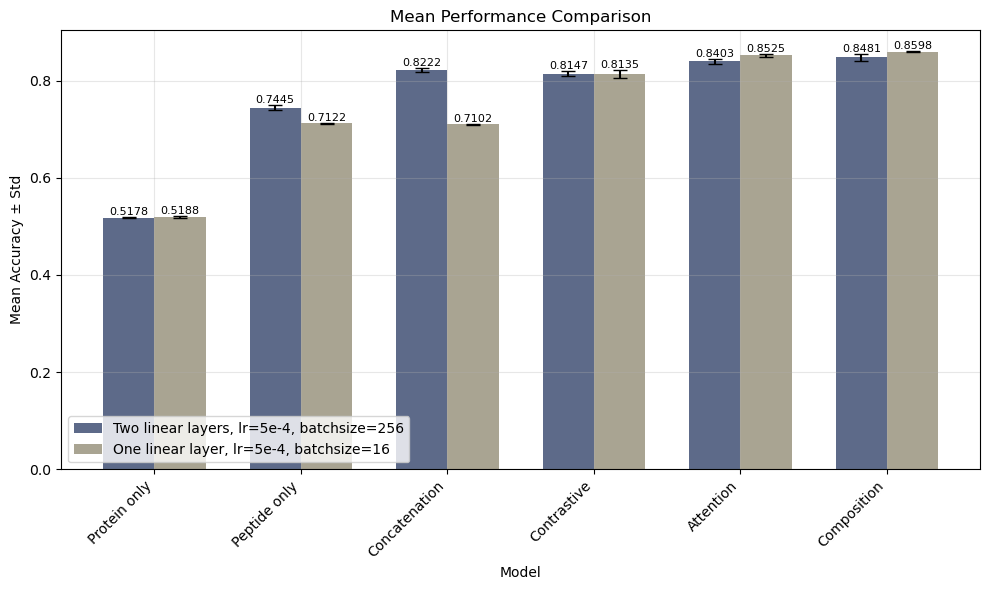


=== Summary Statistics ===

Two linear layers, lr=5e-4, batchsize=256:
        Model     Mean      Std
 Protein only 0.517798 0.001256
 Peptide only 0.744511 0.004760
Concatenation 0.822189 0.004847
  Contrastive 0.814704 0.005336
    Attention 0.840319 0.005064
  Composition 0.848137 0.007752

One linear layer, lr=5e-4, batchsize=16:
        Model     Mean      Std
 Protein only 0.518796 0.002017
 Peptide only 0.712242 0.000288
Concatenation 0.710246 0.000576
  Contrastive 0.813540 0.007989
    Attention 0.852462 0.002561
  Composition 0.859780 0.000998


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load both CSV files
df1 = pd.read_csv('/home/zcorn/Projects/BioLLMComposition/results/results.csv')
df2 = pd.read_csv('/home/zcorn/Projects/BioLLMComposition/results/results_tannerHP.csv')

# Define labels based on experimental conditions
label1 = 'Two linear layers, lr=5e-4, batchsize=256'
label2 = 'One linear layer, lr=5e-4, batchsize=16'

# Calculate mean and std for each dataset
df1['Mean'] = df1[['Run 1', 'Run 2', 'Run 3']].mean(axis=1)
df1['Std'] = df1[['Run 1', 'Run 2', 'Run 3']].std(axis=1)
df2['Mean'] = df2[['Run 1', 'Run 2', 'Run 3']].mean(axis=1)
df2['Std'] = df2[['Run 1', 'Run 2', 'Run 3']].std(axis=1)

# Create figure with single plot
fig, ax2 = plt.subplots(1, 1, figsize=(10, 6))

# Mean with error bars
x = np.arange(len(df1['Model']))
width = 0.35

bars1 = ax2.bar(x - width/2, df1['Mean'], width, yerr=df1['Std'], 
        label=label1, alpha=0.8, capsize=5, color=plt.cm.cividis(0.2))
bars2 = ax2.bar(x + width/2, df2['Mean'], width, yerr=df2['Std'], 
        label=label2, alpha=0.8, capsize=5, color=plt.cm.cividis(0.6))

# Add value labels on top of bars
for i, (bar1, bar2) in enumerate(zip(bars1, bars2)):
    height1 = bar1.get_height()
    height2 = bar2.get_height()
    ax2.text(bar1.get_x() + bar1.get_width()/2., height1 + df1['Std'].iloc[i],
             f'{height1:.4f}', ha='center', va='bottom', fontsize=8)
    ax2.text(bar2.get_x() + bar2.get_width()/2., height2 + df2['Std'].iloc[i],
             f'{height2:.4f}', ha='center', va='bottom', fontsize=8)

ax2.set_xlabel('Model')
ax2.set_ylabel('Mean Accuracy ± Std')
ax2.set_title('Mean Performance Comparison')
ax2.set_xticks(x)
ax2.set_xticklabels(df1['Model'], rotation=45, ha='right')
ax2.legend(loc=3)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/home/zcorn/Projects/BioLLMComposition/results/comparison_plot.png', dpi=300, bbox_inches='tight')
print("Plot saved to comparison_plot.png", flush=True)
plt.show()

# Print summary statistics
print("\n=== Summary Statistics ===", flush=True)
print(f"\n{label1}:", flush=True)
print(df1[['Model', 'Mean', 'Std']].to_string(index=False), flush=True)
print(f"\n{label2}:", flush=True)
print(df2[['Model', 'Mean', 'Std']].to_string(index=False), flush=True)

Plot saved to softmax_comparison.png


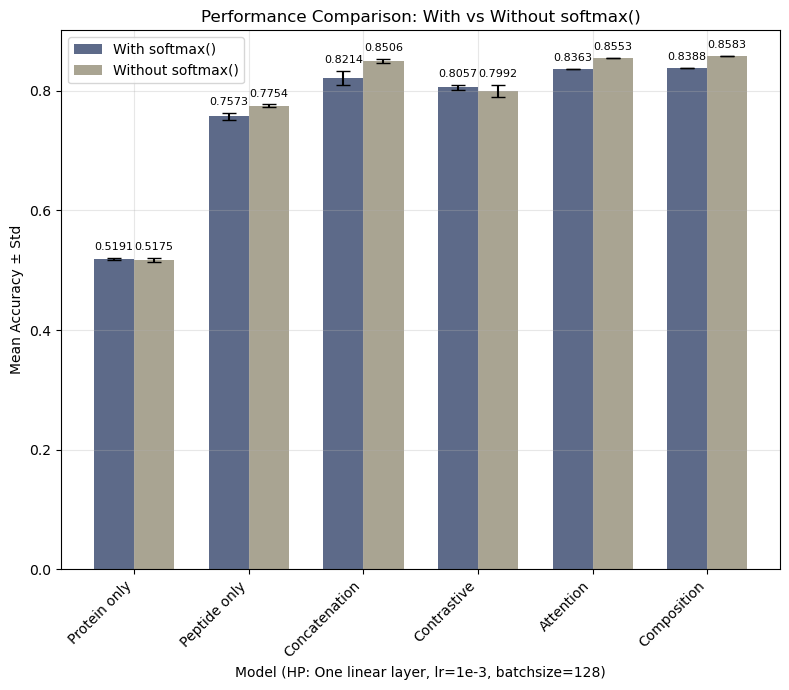


=== Summary Statistics ===

With softmax():
        Model     Mean      Std
 Protein only 0.519128 0.002017
 Peptide only 0.757319 0.005474
Concatenation 0.821357 0.011692
  Contrastive 0.805722 0.004033
    Attention 0.836327 0.000000
  Composition 0.838822 0.000000

Without softmax():
        Model     Mean      Std
 Protein only 0.517465 0.003767
 Peptide only 0.775449 0.001729
Concatenation 0.850632 0.003247
  Contrastive 0.799235 0.010182
    Attention 0.855289 0.000000
  Composition 0.858283 0.000000


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Data with softmax()
data_with_softmax = {
    'Model': ['Protein only', 'Peptide only', 'Concatenation', 'Contrastive', 'Attention', 'Composition'],
    'Run 1': [0.5194610778443114, 0.7529940119760479, 0.813872255489022, 0.810379241516966, 0.8363273453093812, 0.8388223552894212],
    'Run 2': [0.5209580838323353, 0.7554890219560878, 0.8348303393213573, 0.8033932135728543, np.nan, np.nan],
    'Run 3': [0.5169660678642715, 0.7634730538922155, 0.8153692614770459, 0.8033932135728543, np.nan, np.nan]
}

# Data without softmax()
data_without_softmax = {
    'Model': ['Protein only', 'Peptide only', 'Concatenation', 'Contrastive', 'Attention', 'Composition'],
    'Run 1': [0.5139720558882236, 0.7744510978043913, 0.8537924151696606, 0.7904191616766467, 0.8552894211576846, 0.8582834331337326],
    'Run 2': [0.5169660678642715, 0.7774451097804391, 0.8507984031936128, 0.810379241516966, np.nan, np.nan],
    'Run 3': [0.5214570858283433, 0.7744510978043913, 0.8473053892215568, 0.7969061876247505, np.nan, np.nan]
}

df_with = pd.DataFrame(data_with_softmax)
df_without = pd.DataFrame(data_without_softmax)

# Calculate mean and std (handling NaN values)
df_with['Mean'] = df_with[['Run 1', 'Run 2', 'Run 3']].mean(axis=1, skipna=True)
df_with['Std'] = df_with[['Run 1', 'Run 2', 'Run 3']].std(axis=1, skipna=True)
df_with['Std'] = df_with['Std'].fillna(0)  # Set std to 0 for single runs

df_without['Mean'] = df_without[['Run 1', 'Run 2', 'Run 3']].mean(axis=1, skipna=True)
df_without['Std'] = df_without[['Run 1', 'Run 2', 'Run 3']].std(axis=1, skipna=True)
df_without['Std'] = df_without['Std'].fillna(0)  # Set std to 0 for single runs

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(8, 7))

x = np.arange(len(df_with['Model']))
width = 0.35

bars1 = ax.bar(x - width/2, df_with['Mean'], width, yerr=df_with['Std'], 
        label='With softmax()', alpha=0.8, capsize=5, color=plt.cm.cividis(0.2))
bars2 = ax.bar(x + width/2, df_without['Mean'], width, yerr=df_without['Std'], 
        label='Without softmax()', alpha=0.8, capsize=5, color=plt.cm.cividis(0.6))

# Add value labels on top of bars
for i, (bar1, bar2) in enumerate(zip(bars1, bars2)):
    height1 = bar1.get_height()
    height2 = bar2.get_height()
    std1 = df_with['Std'].iloc[i]
    std2 = df_without['Std'].iloc[i]
    ax.text(bar1.get_x() + bar1.get_width()/2., height1 + std1 + 0.01,
             f'{height1:.4f}', ha='center', va='bottom', fontsize=8)
    ax.text(bar2.get_x() + bar2.get_width()/2., height2 + std2 + 0.01,
             f'{height2:.4f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Model (HP: One linear layer, lr=1e-3, batchsize=128)')
ax.set_ylabel('Mean Accuracy ± Std')
ax.set_title('Performance Comparison: With vs Without softmax()')
ax.set_xticks(x)
ax.set_xticklabels(df_with['Model'], rotation=45, ha='right')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/home/zcorn/Projects/BioLLMComposition/results/softmax_comparison.png', dpi=300, bbox_inches='tight')
print("Plot saved to softmax_comparison.png", flush=True)
plt.show()

# Print summary statistics
print("\n=== Summary Statistics ===", flush=True)
print("\nWith softmax():", flush=True)
print(df_with[['Model', 'Mean', 'Std']].to_string(index=False), flush=True)
print("\nWithout softmax():", flush=True)
print(df_without[['Model', 'Mean', 'Std']].to_string(index=False), flush=True)

Plot saved to combined_comparison.png


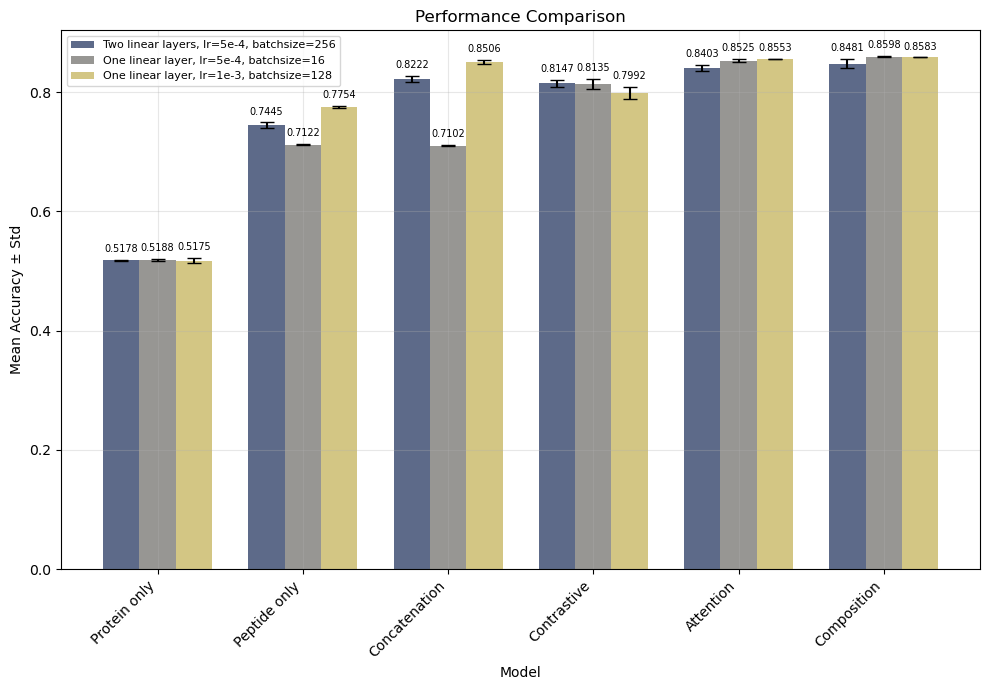


=== Summary Statistics ===

Two linear layers, lr=5e-4, batchsize=256:
        Model     Mean      Std
 Protein only 0.517798 0.001256
 Peptide only 0.744511 0.004760
Concatenation 0.822189 0.004847
  Contrastive 0.814704 0.005336
    Attention 0.840319 0.005064
  Composition 0.848137 0.007752

One linear layer, lr=5e-4, batchsize=16:
        Model     Mean      Std
 Protein only 0.518796 0.002017
 Peptide only 0.712242 0.000288
Concatenation 0.710246 0.000576
  Contrastive 0.813540 0.007989
    Attention 0.852462 0.002561
  Composition 0.859780 0.000998

One linear layer, lr=1e-3, batchsize=128:
        Model     Mean      Std
 Protein only 0.517465 0.003767
 Peptide only 0.775449 0.001729
Concatenation 0.850632 0.003247
  Contrastive 0.799235 0.010182
    Attention 0.855289 0.000000
  Composition 0.858283 0.000000


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load CSV files for first two conditions
df1 = pd.read_csv('/home/zcorn/Projects/BioLLMComposition/results/results.csv')
df2 = pd.read_csv('/home/zcorn/Projects/BioLLMComposition/results/results_tannerHP.csv')

# Data without softmax() (third condition)
data_without_softmax = {
    'Model': ['Protein only', 'Peptide only', 'Concatenation', 'Contrastive', 'Attention', 'Composition'],
    'Run 1': [0.5139720558882236, 0.7744510978043913, 0.8537924151696606, 0.7904191616766467, 0.8552894211576846, 0.8582834331337326],
    'Run 2': [0.5169660678642715, 0.7774451097804391, 0.8507984031936128, 0.810379241516966, np.nan, np.nan],
    'Run 3': [0.5214570858283433, 0.7744510978043913, 0.8473053892215568, 0.7969061876247505, np.nan, np.nan]
}
df3 = pd.DataFrame(data_without_softmax)

# Define labels
label1 = 'Two linear layers, lr=5e-4, batchsize=256'
label2 = 'One linear layer, lr=5e-4, batchsize=16'
label3 = 'One linear layer, lr=1e-3, batchsize=128'

# Calculate mean and std for each dataset
df1['Mean'] = df1[['Run 1', 'Run 2', 'Run 3']].mean(axis=1)
df1['Std'] = df1[['Run 1', 'Run 2', 'Run 3']].std(axis=1)

df2['Mean'] = df2[['Run 1', 'Run 2', 'Run 3']].mean(axis=1)
df2['Std'] = df2[['Run 1', 'Run 2', 'Run 3']].std(axis=1)

df3['Mean'] = df3[['Run 1', 'Run 2', 'Run 3']].mean(axis=1, skipna=True)
df3['Std'] = df3[['Run 1', 'Run 2', 'Run 3']].std(axis=1, skipna=True)
df3['Std'] = df3['Std'].fillna(0)  # Set std to 0 for single runs

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

x = np.arange(len(df1['Model']))
width = 0.25

bars1 = ax.bar(x - width, df1['Mean'], width, yerr=df1['Std'], 
        label=label1, alpha=0.8, capsize=5, color=plt.cm.cividis(0.2))
bars2 = ax.bar(x, df2['Mean'], width, yerr=df2['Std'], 
        label=label2, alpha=0.8, capsize=5, color=plt.cm.cividis(0.5))
bars3 = ax.bar(x + width, df3['Mean'], width, yerr=df3['Std'], 
        label=label3, alpha=0.8, capsize=5, color=plt.cm.cividis(0.8))

# Add value labels on top of bars
for i, (bar1, bar2, bar3) in enumerate(zip(bars1, bars2, bars3)):
    height1 = bar1.get_height()
    height2 = bar2.get_height()
    height3 = bar3.get_height()
    std1 = df1['Std'].iloc[i]
    std2 = df2['Std'].iloc[i]
    std3 = df3['Std'].iloc[i]
    
    ax.text(bar1.get_x() + bar1.get_width()/2., height1 + std1 + 0.01,
             f'{height1:.4f}', ha='center', va='bottom', fontsize=7)
    ax.text(bar2.get_x() + bar2.get_width()/2., height2 + std2 + 0.01,
             f'{height2:.4f}', ha='center', va='bottom', fontsize=7)
    ax.text(bar3.get_x() + bar3.get_width()/2., height3 + std3 + 0.01,
             f'{height3:.4f}', ha='center', va='bottom', fontsize=7)

ax.set_xlabel('Model')
ax.set_ylabel('Mean Accuracy ± Std')
ax.set_title('Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(df1['Model'], rotation=45, ha='right')
ax.legend(loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/home/zcorn/Projects/BioLLMComposition/results/combined_comparison.png', dpi=300, bbox_inches='tight')
print("Plot saved to combined_comparison.png", flush=True)
plt.show()

# Print summary statistics
print("\n=== Summary Statistics ===", flush=True)
print(f"\n{label1}:", flush=True)
print(df1[['Model', 'Mean', 'Std']].to_string(index=False), flush=True)
print(f"\n{label2}:", flush=True)
print(df2[['Model', 'Mean', 'Std']].to_string(index=False), flush=True)
print(f"\n{label3}:", flush=True)
print(df3[['Model', 'Mean', 'Std']].to_string(index=False), flush=True)

Plot saved to proteinDNA_summary.png


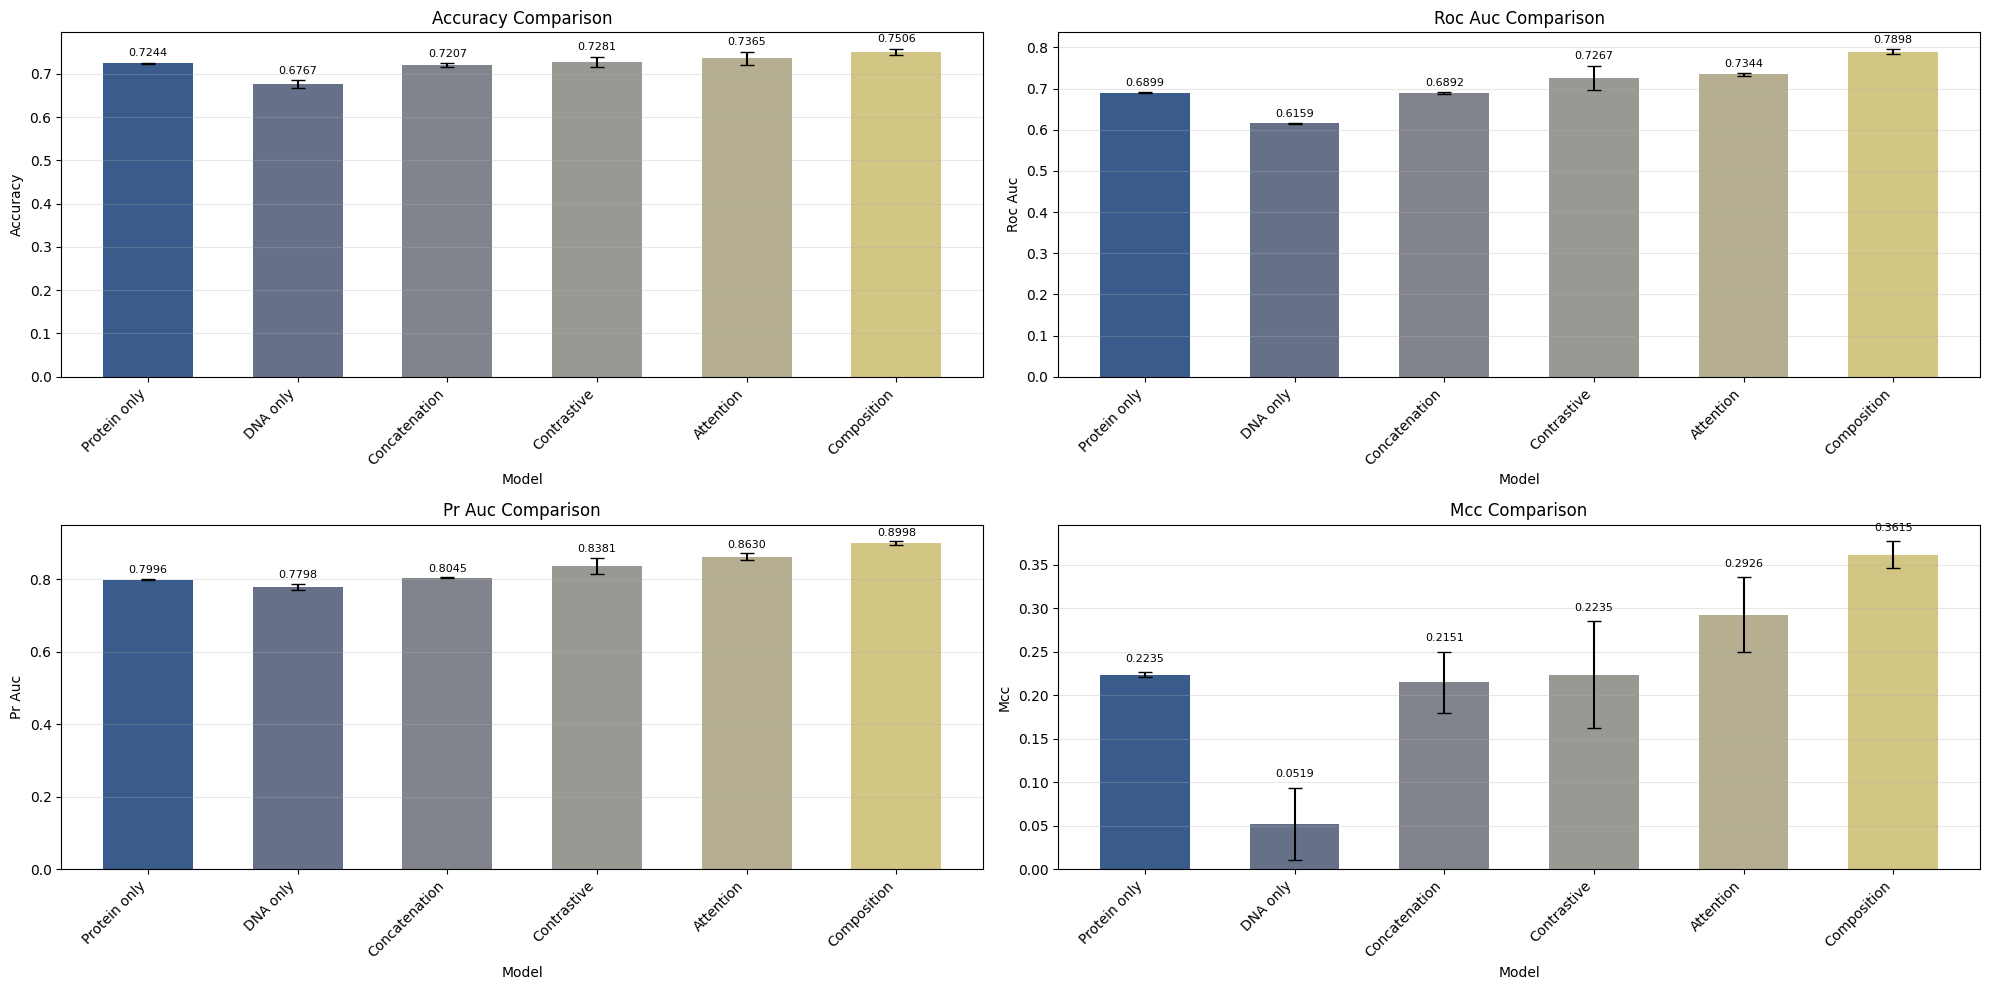


=== Summary Statistics ===
        Model        accuracy         roc_auc          pr_auc             mcc
 Protein only 0.7244 ± 0.0018 0.6899 ± 0.0019 0.7996 ± 0.0018 0.2235 ± 0.0029
     DNA only 0.6767 ± 0.0093 0.6159 ± 0.0012 0.7798 ± 0.0076 0.0519 ± 0.0417
Concatenation 0.7207 ± 0.0042 0.6892 ± 0.0027 0.8045 ± 0.0016 0.2151 ± 0.0350
  Contrastive 0.7281 ± 0.0119 0.7267 ± 0.0292 0.8381 ± 0.0220 0.2235 ± 0.0614
    Attention 0.7365 ± 0.0149 0.7344 ± 0.0031 0.8630 ± 0.0087 0.2926 ± 0.0430
  Composition 0.7506 ± 0.0075 0.7898 ± 0.0069 0.8998 ± 0.0057 0.3615 ± 0.0155


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re

# Load the CSV file
df = pd.read_csv('/home/zcorn/Projects/BioLLMComposition/results/results_tannerHP_ProteinDNA_summary.csv')

# Parse the metrics (they're in format "value ± std")
def parse_metric(value):
    """Parse 'value ± std' format into (mean, std)"""
    match = re.match(r'([\d.]+)\s*±\s*([\d.]+)', str(value))
    if match:
        return float(match.group(1)), float(match.group(2))
    return float(value), 0.0

# Extract mean and std for each metric
metrics = ['accuracy', 'roc_auc', 'pr_auc', 'mcc']
for metric in metrics:
    df[f'{metric}_mean'] = df[metric].apply(lambda x: parse_metric(x)[0])
    df[f'{metric}_std'] = df[metric].apply(lambda x: parse_metric(x)[1])

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(20, 10))
axes = axes.flatten()

# Plot each metric
for idx, metric in enumerate(metrics):
    ax = axes[idx]
    x = np.arange(len(df['Model']))
    width = 0.6
    
    bars = ax.bar(x, df[f'{metric}_mean'], width, yerr=df[f'{metric}_std'], 
                   alpha=0.8, capsize=5, color=plt.cm.cividis(np.linspace(0.1, 0.8, len(df))))
    
    # Add value labels on top of bars
    for i, bar in enumerate(bars):
        height = bar.get_height()
        std_val = df[f'{metric}_std'].iloc[i]
        ax.text(bar.get_x() + bar.get_width()/2., height + std_val + 0.01,
                f'{height:.4f}', ha='center', va='bottom', fontsize=8)
    
    ax.set_xlabel('Model')
    ax.set_ylabel(metric.replace('_', ' ').title())
    ax.set_title(f'{metric.replace("_", " ").title()} Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels(df['Model'], rotation=45, ha='right')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/home/zcorn/Projects/BioLLMComposition/results/proteinDNA_summary.png', dpi=300, bbox_inches='tight')
print("Plot saved to proteinDNA_summary.png", flush=True)
plt.show()

# Print summary
print("\n=== Summary Statistics ===", flush=True)
print(df[['Model'] + metrics].to_string(index=False), flush=True)

In [30]:
import pandas as pd

# Load the specified parquet file
parquet_path = '/home/zcorn/Projects/proteinDNA_data/working/dnaprodb2/dna_protein_chain_wise_cleaned.parquet'
df_parquet = pd.read_parquet(parquet_path)
print("Loaded parquet file:", parquet_path)
print("Shape:", df_parquet.shape)
print(df_parquet.head())

Loaded parquet file: /home/zcorn/Projects/proteinDNA_data/working/dnaprodb2/dna_protein_chain_wise_cleaned.parquet
Shape: (45533, 7)
   pdb_id prot_chain_id dna_chain_id  \
6    3bq2             A            P   
7    3bq2             A            T   
8    3exj             A            C   
9    3exj             A            D   
10   3exj             A            C   

                                             prot_seq       dna_seq  label  \
6   MIVIFVDFDYFFAQVEEVLNPQYKGKPLVVCVYSGTSGAVATANYE...   GAAGCCGGCGG      1   
7   MIVIFVDFDYFFAQVEEVLNPQYKGKPLVVCVYSGTSGAVATANYE...  CCGCCCGGCTTC      1   
8   KTYQGNYGFHLGFLQSGTAKSVMCTYSPPLNKLFCQLAKTCPVQLW...   GAGCATGCTCA      1   
9   KTYQGNYGFHLGFLQSGTAKSVMCTYSPPLNKLFCQLAKTCPVQLW...  TTGAGCATGCTC      1   
10  KTYQGNYGFHLGFLQSGTAKSVMCTYSPPLNKLFCQLAKTCPVQLW...   GAGCATGCTCA      1   

    cluster_id  
6         2249  
7         2249  
8         8232  
9         8232  
10        8232  


(45533, 7)